## Introduction

### Problem Statement

Forecasting cryptocurrency prices, particularly Bitcoin, is a challenging yet valuable task due to the asset’s high volatility and market sensitivity. Investors, analysts, and trading platforms rely on timely insights to make informed decisions. The problem this project addresses is: how can we build a reliable, real-time forecasting system that predicts short-term Bitcoin price movements using both historical and live data? By leveraging Facebook Prophet, a time series forecasting tool, the project aims to process noisy and irregular financial data, model seasonality and trends, and produce accurate, interpretable forecasts. The solution must also be robust to missing data, flexible for customization, and scalable enough for real-time applications.

---

### Learning Objectives
- Apply Facebook Prophet to real-world time series data.
- Ingest real-time Bitcoin prices from a public API.
- Clean, transform, and merge historical and live data.
- Visualize trends and generate 7–30 day forecasts.
- Evaluate forecasting accuracy using RMSE/MAE.
- Build an interactive web dashboard using Streamlit.

---

### Technologies Used

| Component        | Library/Tool        |
|------------------|---------------------|
| Forecasting      | `prophet`           |
| Data Handling    | `pandas`, `numpy`   |
| API Access       | `requests`, `json`  |
| Visualization    | `matplotlib`, `plotly` |
| Evaluation       | `sklearn.metrics`   |
| Web Dashboard    | `streamlit`         |      

---

### Key Features of Facebook Prophet
- Automatic detection of yearly, weekly, and daily seasonality.
- Robust to missing data and outliers.
- Supports holiday effects and custom seasonality.
- User-friendly syntax for rapid experimentation and tuning.

---

### Data Sources
- **Historical Data**: Kaggle Bitcoin dataset (2013–2025)
- **Real-Time Data**: CoinGecko API – `/coins/bitcoin/market_chart`

---

### Python Libraries Required
- `prophet`
- `pandas`
- `numpy`
- `matplotlib`
- `plotly`
- `requests`
- `sklearn.metrics`
- `streamlit` 


## **DATA INGESTION**

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../scripts'))

In [2]:
from utils import (load_historical_data,fetch_live_data,merge_and_clean_data,create_prophet_model,
                             train_prophet_model,make_forecast,plot_forecast)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
%matplotlib inline
import seaborn as sns
import requests
import warnings
import scipy.stats as stats
from scipy.stats import shapiro, normaltest,zscore
warnings.filterwarnings('ignore')

In [4]:
# Load historical Bitcoin data
historical_btc_df = load_historical_data('../data/bitcoin_historical_data.csv')
historical_btc_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [5]:
# Fetch live Bitcoin prices from API
live_btc_df = fetch_live_data(days=365, currency='usd')
live_btc_df.head()

,ds,y
0,2024-05-02,58297.574075
1,2024-05-03,59135.173361
2,2024-05-04,62839.340736
3,2024-05-05,63820.451903
4,2024-05-06,64010.008652


In [6]:
# Merge historical and live data
bitcoin_data_df = merge_and_clean_data(historical_btc_df, live_btc_df)
bitcoin_data_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [7]:
bitcoin_data_df.shape

(4870, 2)

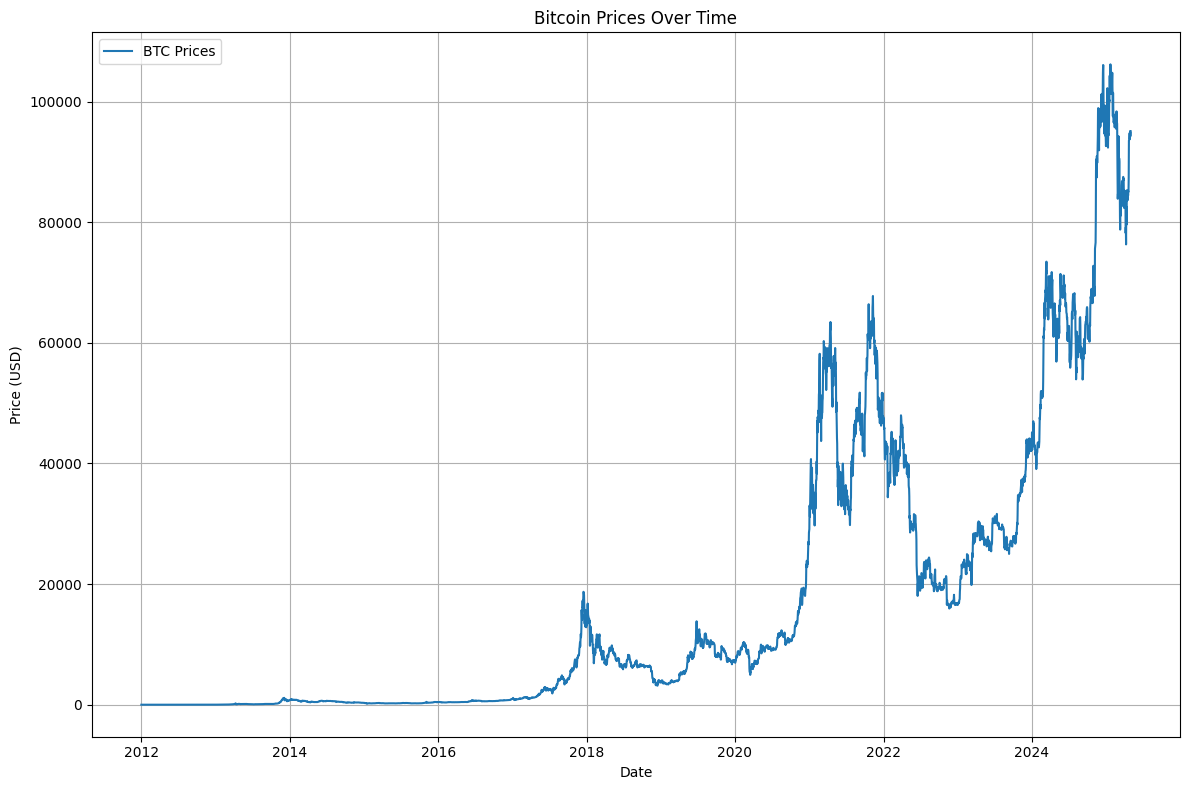

In [8]:
plt.figure(figsize=(12,8))
plt.plot(bitcoin_data_df['ds'], bitcoin_data_df['y'], label='BTC Prices')
plt.title('Bitcoin Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()  
plt.tight_layout()
plt.show()

## **EXPLORATORY DATA ANALYSIS**

### Dataset Overview

In [9]:
# Time range
print("Start Date:", bitcoin_data_df['ds'].min())
print("End Date:", bitcoin_data_df['ds'].max())
bitcoin_data_df.sort_values('ds',inplace=True)

Start Date: 2012-01-01 00:00:00
End Date: 2025-05-01 00:00:00


In [10]:
# Total records 
print("total Daily records:",len(bitcoin_data_df))

total Daily records: 4870


In [11]:
print('Statistics Summary of our Dataset:')
bitcoin_data_df.describe()

Statistics Summary of our Dataset:


,ds,y
count,4870,4870.00000
mean,2018-08-31 12:00:00,17414.66615
min,2012-01-01 00:00:00,4.38000
25%,2015-05-02 06:00:00,424.51000
50%,2018-08-31 12:00:00,6609.83000
75%,2021-12-30 18:00:00,27273.00000
max,2025-05-01 00:00:00,106182.23682
std,NaN,24066.11574


This dataset contains 4,869 daily Bitcoin price records from January 1, 2012, to April 30, 2025, with no missing entries or duplicate dates, indicating a complete and continuous time series. The prices range from a minimum of 4.38 dollars to a maximum of 106,182.24 dollars, with an average of approximately 17,399.56 dollars and a median of 6,603.82 dollars, suggesting a right-skewed distribution due to sharp price increases in recent years. The standard deviation of 24,044.35 dollars reflects substantial volatility, and the wide range between the 25th percentile (424.45 dollars) and the 75th percentile (27,267.00 dollars) indicates the presence of significant outliers. These outliers, often driven by speculative surges, are crucial to consider when building reliable forecasting models like Facebook Prophet.


### DATA QUALITY CHECKS

In [12]:
print("The number of missing entries:")
bitcoin_data_df.isnull().sum()

The number of missing entries:


ds    0
y     0
dtype: int64

In [13]:
# Check for missing days (gap in timeline)
expected_dates = pd.date_range(start=bitcoin_data_df['ds'].min(), end=bitcoin_data_df['ds'].max(), freq='D')
actual_dates = pd.to_datetime(bitcoin_data_df['ds'])
missing_days = expected_dates.difference(actual_dates)
print(f"\nNumber of missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print("Missing dates:", missing_days[:5])


Number of missing days: 0


We verified that the dataset has no missing values in either the ds (date) or y (price) columns, and there are no missing days in the time series. This confirms that the data is clean, complete, and continuous which is ideal for Facebook Prophet, as it relies on regular daily intervals to accurately model trends and seasonality.

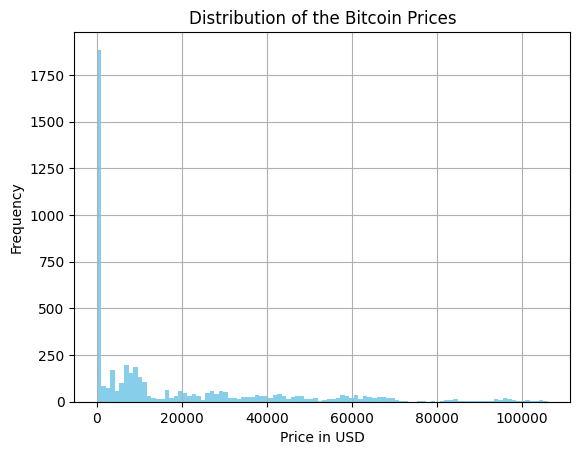

In [14]:
# understanding distribution of the data
plt.hist(bitcoin_data_df['y'],bins=100,color='skyblue')
plt.title('Distribution of the Bitcoin Prices')
plt.xlabel('Price in USD')
plt.ylabel('Frequency')
plt.grid(True)

The distribution of Bitcoin prices is highly right-skewed, with most prices concentrated in the lower range (under 10,000 dollars). A sharp peak is observed at low price levels, while higher prices (above 20,000 dollars) occur less frequently but stretch out over a long tail up to 100,000+ dollars. This confirms the presence of extreme outliers and exponential growth over time.

Text(0.5, 1.0, 'QQ Plot for the bitcoin Prices')

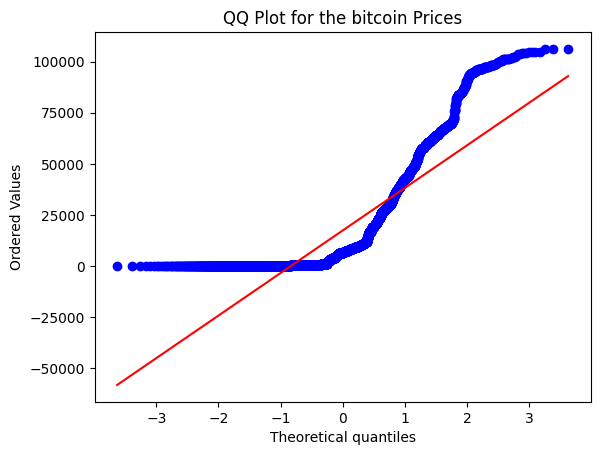

In [15]:
stats.probplot(bitcoin_data_df['y'], dist="norm",plot=plt)
plt.title("QQ Plot for the bitcoin Prices")

The QQ plot shows that Bitcoin prices are not normally distributed, displaying a heavy right skew and extreme outliers. This is typical for financial time series data and supports the use of models like Facebook Prophet, which do not assume normality and can handle irregular patterns effectively.

In [16]:
# Checking the number of potential outliers
from scipy.stats import zscore
z_score=zscore(bitcoin_data_df['y'])
outliers= bitcoin_data_df[z_score>3]
print(f'\nThe number of potential outliers:{len(outliers)}')
print(outliers[['ds','y']].head())


The number of potential outliers:115
             ds             y
4701 2024-11-14  90488.100075
4703 2024-11-16  90947.975094
4704 2024-11-17  90606.454894
4705 2024-11-18  89841.471941
4706 2024-11-19  90534.624597


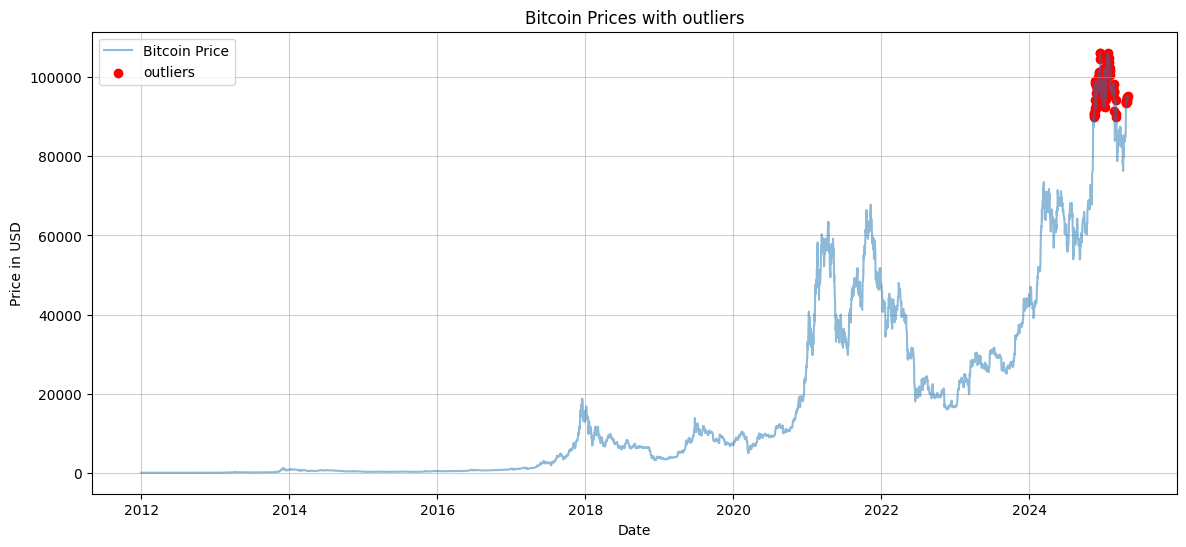

In [17]:
plt.figure(figsize=(14,6))
plt.plot(bitcoin_data_df['ds'],bitcoin_data_df['y'],label='Bitcoin Price',alpha=0.5)
plt.scatter(outliers['ds'],outliers['y'],color='red', label='outliers')
plt.title('Bitcoin Prices with outliers')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

- The Bitcoin price trend graph shows a clear long-term upward movement from 2012 to 2025, beginning at just a few dollars and reaching over 100,000 dollars. Major price spikes are observed in 2017, 2021, and again in 2024, each followed by noticeable crashes, highlighting the asset's highly volatile nature. These movements reflect visible cycles of rapid growth (bull runs) followed by sharp corrections (bear markets). 
- The pattern of rise → fall → rise again is a defining feature of Bitcoin’s historical behavior. Overall, the graph reveals a non-linear upward trend with extreme fluctuations, underscoring the need for robust forecasting tools like Facebook Prophet, which can handle such irregularities and capture both trend and seasonality in volatile financial data.

### Seasonality and Patterns

In [18]:
btc_df = bitcoin_data_df.copy()

In [19]:
btc_df['ds'] = pd.to_datetime(btc_df['ds'])
btc_df = btc_df.sort_values('ds')

In [20]:
btc_df['year']=btc_df['ds'].dt.year
btc_df['month']=btc_df['ds'].dt.month_name()
btc_df['weekday']=btc_df['ds'].dt.day_name()

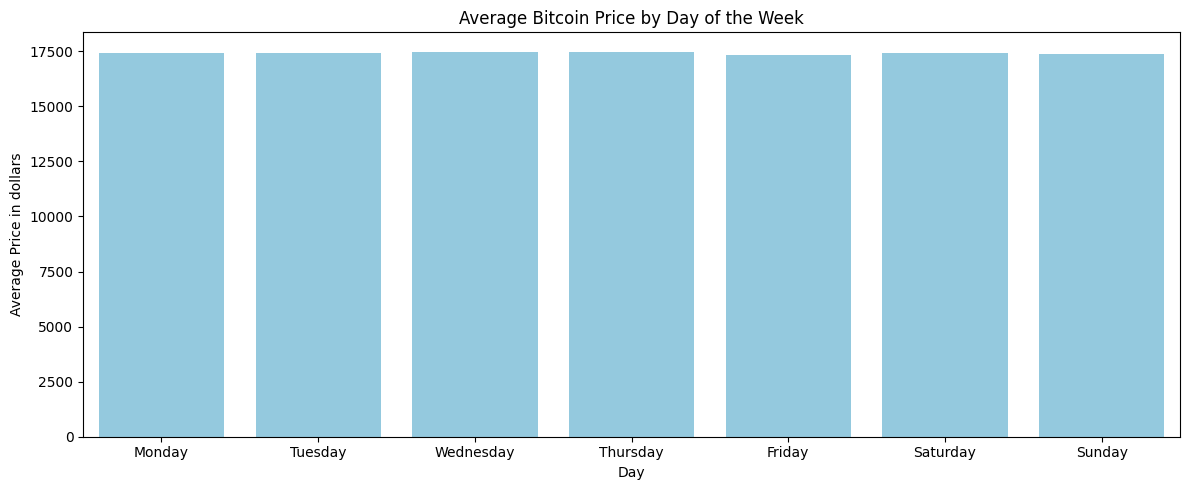

In [21]:
# Weekly Trends
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = (btc_df.groupby('weekday')['y'].mean().reindex(weekday_order).reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(data=weekday_avg, x='weekday', y='y', order=weekday_order, color='skyblue')
plt.title('Average Bitcoin Price by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Average Price in dollars')
plt.tight_layout()
plt.show()

The bar plot shows that the average Bitcoin price remains consistent across all days of the week, with very minimal variation. No weekday stands out as significantly higher or lower in average price. This reinforces the conclusion from the boxplot that there is no meaningful weekly seasonality in the data, and Bitcoin’s price movements appear independent of the day of the week, which is useful to know when preparing features for time series forecasting.

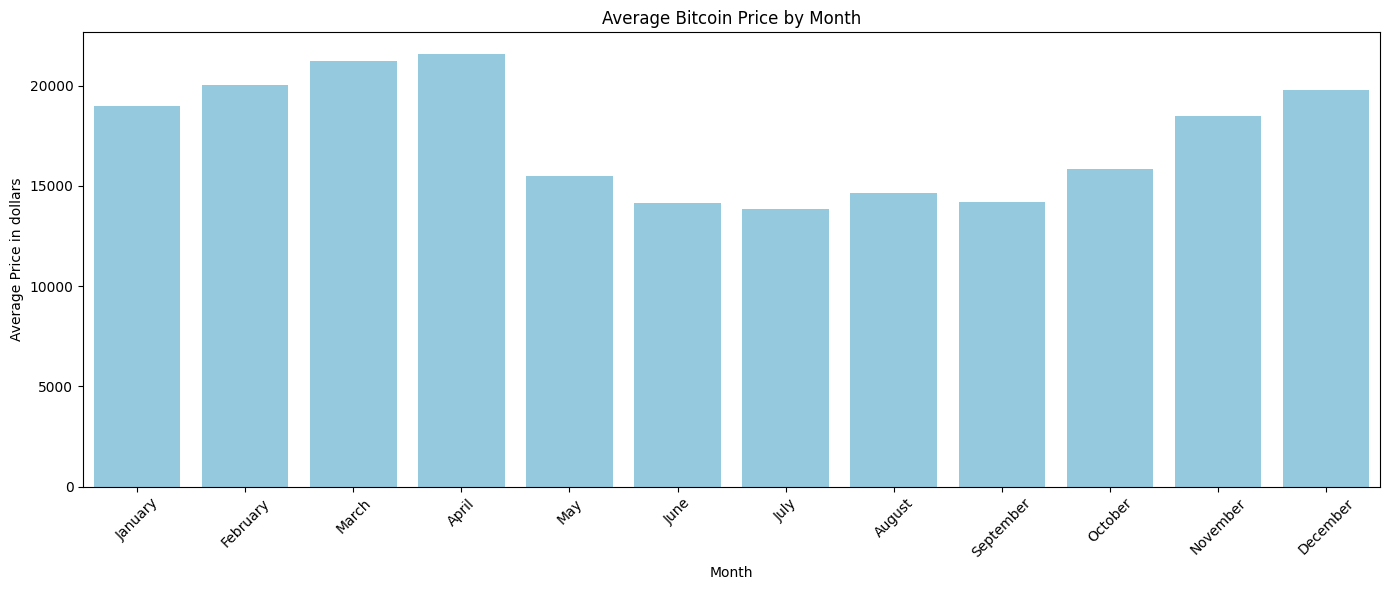

In [22]:
# Montly Trend
month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 
               'November', 'December']
monthly_avg = btc_df.groupby('month')['y'].mean().reindex(month_order).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=monthly_avg, x='month', y='y', order=month_order, color='skyblue')
plt.title('Average Bitcoin Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price in dollars')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar plot shows noticeable **monthly variation** in average Bitcoin prices. Prices tend to be higher from **January through April**, peaking in **March and April**, and lower during the **mid-year months**, especially **June through September**. This pattern suggests the presence of a **mild yearly seasonality**, with early and late-year months generally showing stronger price performance than the middle of the year. This insight is useful when deciding whether to include **yearly seasonal components** in the forecasting model.

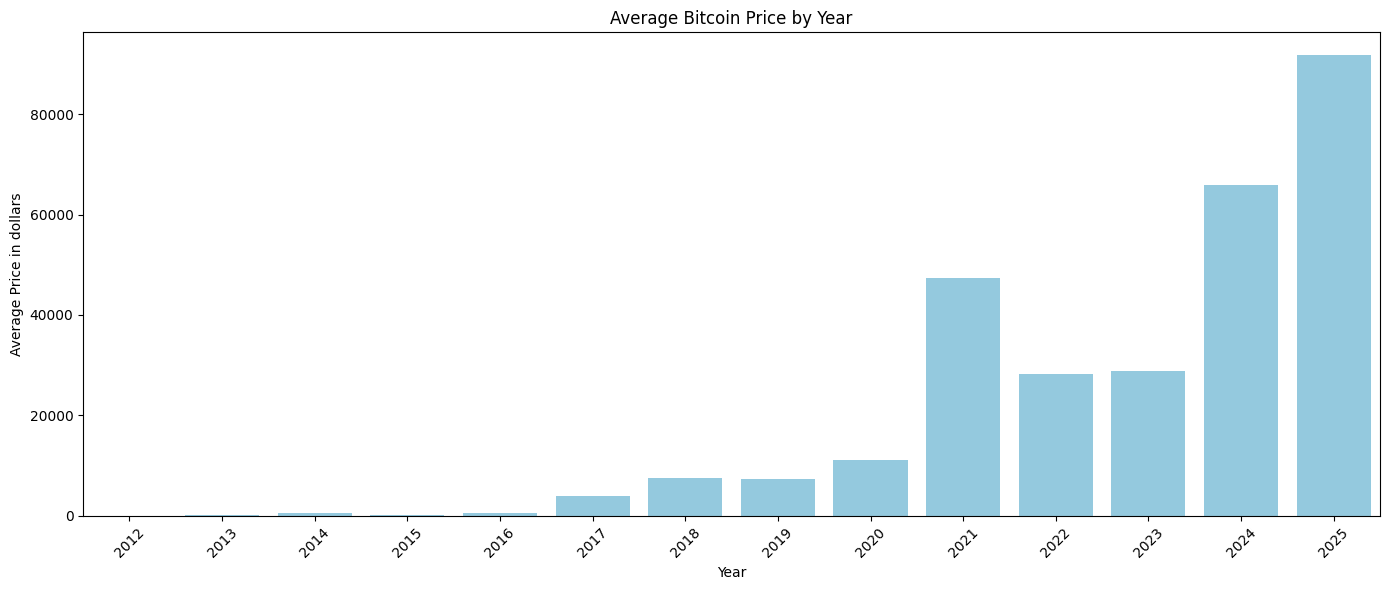

In [23]:
#Yearly Trend
yearly_avg = btc_df.groupby('year')['y'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=yearly_avg, x='year', y='y', color='skyblue')
plt.title('Average Bitcoin Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price in dollars')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The plot reveals that Bitcoin's yearly price behavior is shaped by repeating boom-and-correction cycles. The initial spike in 2017 reflects a speculative surge as Bitcoin entered mainstream attention. The drop in 2018 corresponds to the post-hype correction. A similar pattern occurs in 2021, driven by institutional interest and global economic factors, followed by a decline in 2022 amid market tightening. The strong rebound in 2024 and 2025 likely reflects renewed adoption or macroeconomic shifts. These shifts suggest that external market events, investor sentiment, and macro cycles have a significant influence on trend structure — an important consideration when identifying change points and modeling long-term dynamics in the time series

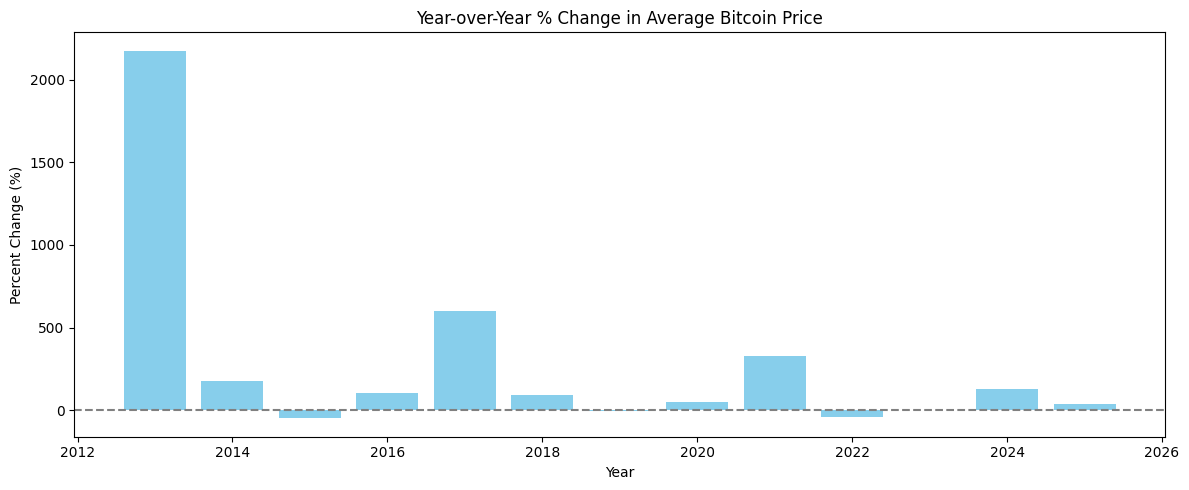

In [24]:
# detecting significant price increase or crash
btc_df['year'] = btc_df['ds'].dt.year
yearly_avg = btc_df.groupby('year')['y'].mean()
yearly_change = yearly_avg.pct_change()

plt.figure(figsize=(12, 5))
plt.bar(yearly_change.index[1:], yearly_change.values[1:] * 100, color='skyblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Year-over-Year % Change in Average Bitcoin Price')
plt.xlabel('Year')
plt.ylabel('Percent Change (%)')
plt.tight_layout()
plt.show()

The year-over-year percent change chart shows that Bitcoin's price history is marked by highly irregular growth patterns, with extreme surges in 2013 and smaller, but notable, spikes in 2017, 2021, and 2024. Some years, such as 2015 and 2022, show mild negative returns, reflecting temporary market corrections. These fluctuations indicate the presence of non-linear trends, sharp growth cycles, and potential structural changes in the time series — all of which are important to capture accurately in forecasting.

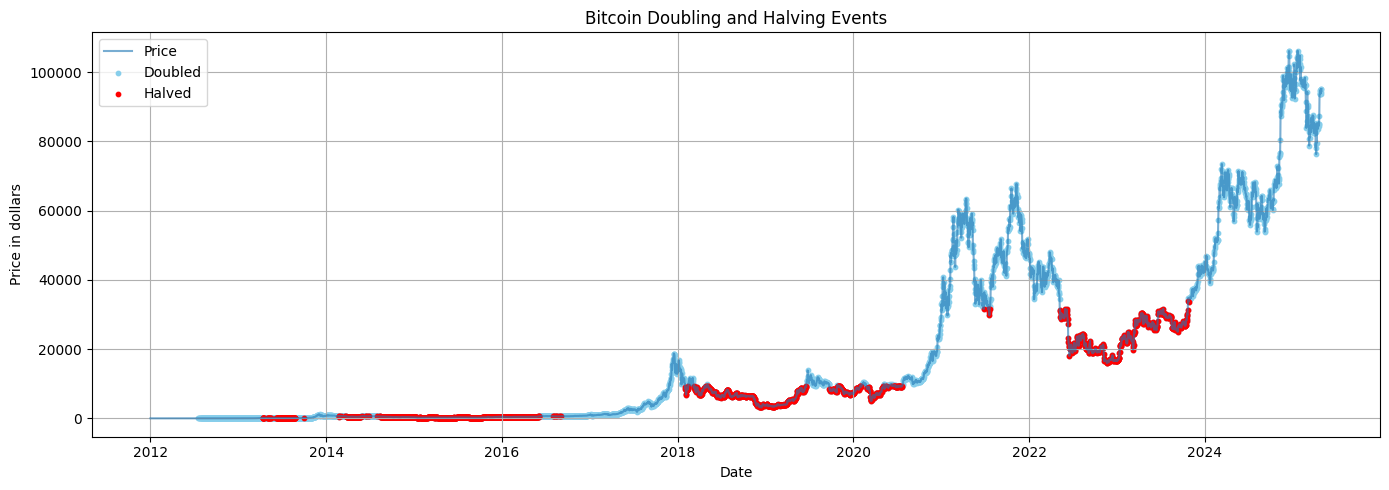

In [25]:
# Doubling and halving events
btc_df['cummin'] = btc_df['y'].cummin()
btc_df['cummax'] = btc_df['y'].cummax()
btc_df['doubled'] = btc_df['y'] >= 2 * btc_df['cummin']
btc_df['halved'] = btc_df['y'] <= 0.5 * btc_df['cummax']

plt.figure(figsize=(14, 5))
plt.plot(btc_df['ds'], btc_df['y'], label='Price', alpha=0.6)
plt.scatter(btc_df[btc_df['doubled']]['ds'], btc_df[btc_df['doubled']]['y'], color='skyblue', s=10, label='Doubled')
plt.scatter(btc_df[btc_df['halved']]['ds'], btc_df[btc_df['halved']]['y'], color='red', s=10, label='Halved')
plt.title('Bitcoin Doubling and Halving Events')
plt.xlabel('Date')
plt.ylabel('Price in dollars')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot reveals that Bitcoin's price has undergone multiple doubling and halving events over time, with halving points (red) clustering around market corrections and doubling points (blue) appearing during strong uptrends, especially in 2017, 2021, and 2024. These events reflect Bitcoin’s characteristic boom-and-bust cycles, emphasizing the need to account for sharp directional changes and localized volatility when analyzing temporal dynamics for forecasting.

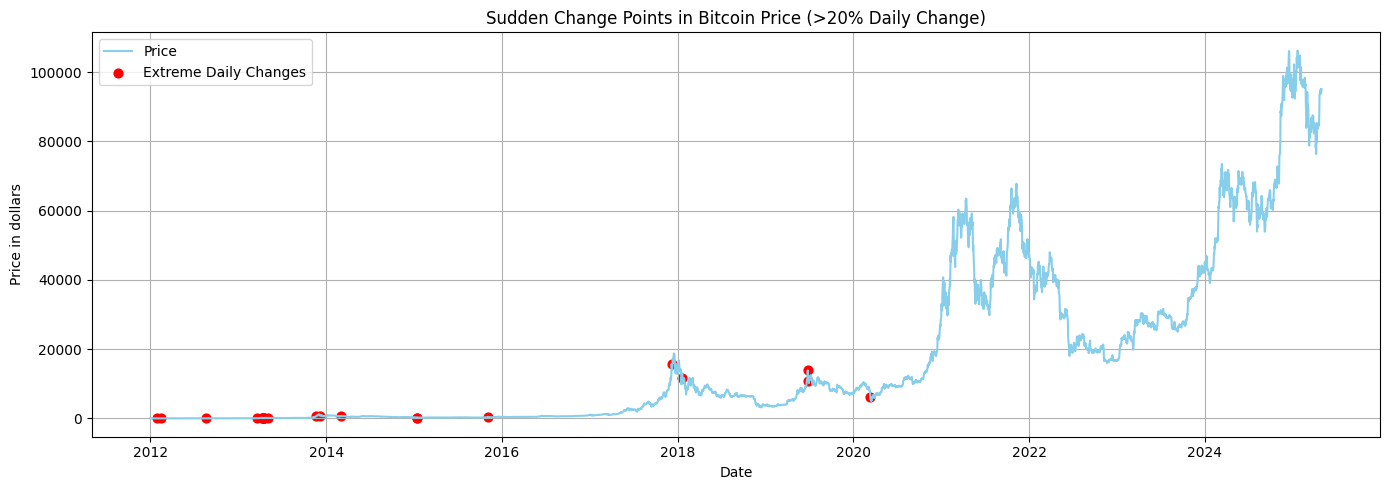

In [26]:
# Structural change points: daily change > 20%
btc_df['pct_change'] = (btc_df['y'] - btc_df['y'].shift(1)) / btc_df['y'].shift(1)
change_points = btc_df[btc_df['pct_change'].abs() > 0.2]

plt.figure(figsize=(14, 5))
plt.plot(btc_df['ds'], btc_df['y'], label='Price',color='skyblue')
plt.scatter(change_points['ds'], change_points['y'], color='red', label='Extreme Daily Changes', s=40)
plt.title('Sudden Change Points in Bitcoin Price (>20% Daily Change)')
plt.xlabel('Date')
plt.ylabel('Price in dollars')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot shows that extreme daily price changes (>20%) are mostly concentrated in the early years and around major market events like 2017 and 2020. These are short-term volatility spikes, not structural trend changes, but they highlight periods of **high market instability** that can affect forecast accuracy and should be considered when handling outliers or setting confidence intervals in time series modeling.